# Non-Parametric Tests

## Overview

Rank-based alternatives when normality is not reasonable. Robust to outliers, appropriate for ordinal data and small heavily-skewed samples.

| Parametric | Non-parametric | scipy |
|---|---|---|
| One-sample t | Wilcoxon signed-rank | `wilcoxon` |
| Two-sample t | Mann-Whitney U | `mannwhitneyu` |
| Paired t | Wilcoxon signed-rank | `wilcoxon` |
| One-way ANOVA | Kruskal-Wallis | `kruskal` |

---

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
ctrl  = rng.negative_binomial(3, 0.35, 60)
rest  = rng.negative_binomial(4, 0.30, 60)
before = rng.poisson(8, 40)
after  = before + rng.integers(-2, 5, 40)
g4 = [rng.negative_binomial(k, 0.35, 40) for k in [2,3,4,5]]
print(f"Control  median={np.median(ctrl):.1f}, IQR={np.percentile(ctrl,75)-np.percentile(ctrl,25):.1f}")
print(f"Restored median={np.median(rest):.1f}, IQR={np.percentile(rest,75)-np.percentile(rest,25):.1f}")

Control  median=5.0, IQR=5.2
Restored median=7.5, IQR=9.0


---
## Mann-Whitney U (two independent samples)

Mann-Whitney U=2434, p=0.0009
Rank-biserial r=-0.352  (small=0.1, medium=0.3, large>=0.5)


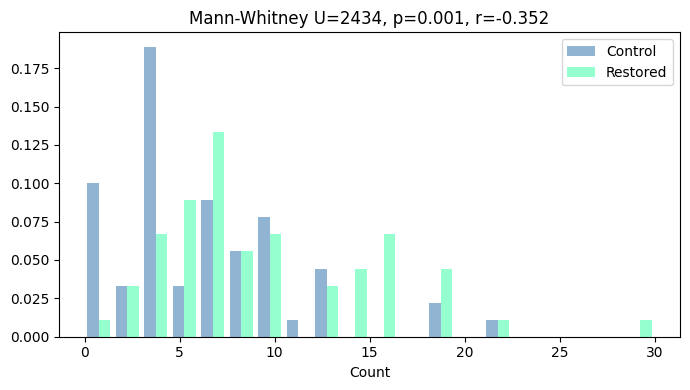

In [2]:
U, p = stats.mannwhitneyu(rest, ctrl, alternative="two-sided")
r_rb = 1 - (2*U)/(len(ctrl)*len(rest))
print(f"Mann-Whitney U={U:.0f}, p={p:.4f}")
print(f"Rank-biserial r={r_rb:.3f}  (small=0.1, medium=0.3, large>=0.5)")
fig, ax = plt.subplots(figsize=(7,4))
ax.hist([ctrl, rest], bins=20, density=True, alpha=0.6,
        color=["steelblue","#4fffb0"], label=["Control","Restored"])
ax.set_xlabel("Count"); ax.legend()
ax.set_title(f"Mann-Whitney U={U:.0f}, p={p:.3f}, r={r_rb:.3f}")
plt.tight_layout(); plt.show()

---
## Wilcoxon Signed-Rank (paired / one-sample)

In [3]:
W, p = stats.wilcoxon(after, before, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={W:.0f}, p={p:.4f}")
print(f"Median difference: {np.median(after-before):.2f}")
t_w, p_w = stats.ttest_rel(after, before)
print(f"Comparison -- paired t: p={p_w:.4f}")

Wilcoxon signed-rank: W=140, p=0.0064
Median difference: 1.00
Comparison -- paired t: p=0.0037


---
## Kruskal-Wallis (3+ groups) with post-hoc

Kruskal-Wallis: H=36.382, p=0.0000, eta2=0.214
Post-hoc: scikit_posthocs.posthoc_dunn(groups, p_adjust='bonferroni')


C:\Users\saman\AppData\Local\Temp\ipykernel_11684\3402366500.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(g4, labels=["k=2","k=3","k=4","k=5"], patch_artist=True)


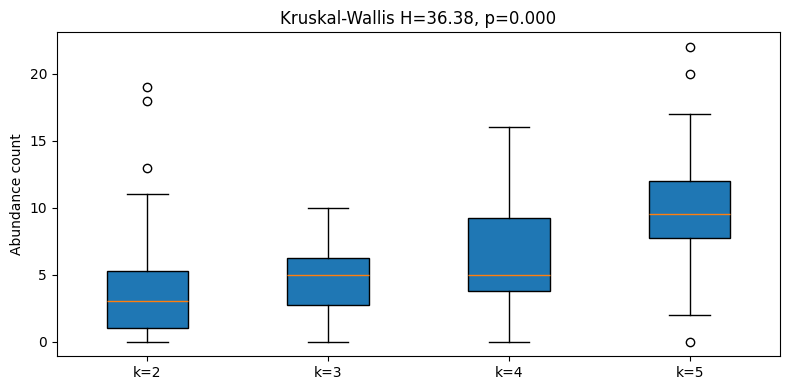

In [4]:
H, p = stats.kruskal(*g4)
N = sum(len(g) for g in g4)
eta2 = (H - len(g4)+1)/(N - len(g4))
print(f"Kruskal-Wallis: H={H:.3f}, p={p:.4f}, eta2={eta2:.3f}")
print("Post-hoc: scikit_posthocs.posthoc_dunn(groups, p_adjust='bonferroni')")
# Visualise
fig, ax = plt.subplots(figsize=(8,4))
ax.boxplot(g4, labels=["k=2","k=3","k=4","k=5"], patch_artist=True)
ax.set_ylabel("Abundance count")
ax.set_title(f"Kruskal-Wallis H={H:.2f}, p={p:.3f}")
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Assuming non-parametric tests are fully assumption-free**  
Mann-Whitney U tests stochastic dominance, not specifically medians. It assumes the two distributions have the same shape under the null. Substantially different shapes require careful interpretation.

**2. Interpreting Mann-Whitney as a test of medians**  
Mann-Whitney tests whether one distribution tends to produce larger values, not specifically median differences. Do not report it as a median test unless both distributions have the same shape and scale.

**3. Low power for small samples regardless of test choice**  
For n < 10 per group all tests have low power. Non-parametric tests are slightly less powerful than parametric ones when normality holds. Check power before interpreting non-significant results.

**4. No post-hoc tests after significant Kruskal-Wallis**  
Kruskal-Wallis is omnibus. Use Dunn's test with Bonferroni or BH correction to identify which pairs differ.

**5. Using Kruskal-Wallis for heavily tied data without considering permutation tests**  
Many tied ranks degrade the chi-square approximation. For highly discrete or ordinal data with many ties, use `scipy.stats.permutation_test` for greater accuracy.

---
*python_methods_library - Samantha McGarrigle*